# XY $32\times32$: clean three-phase raw PCA vs frozen ResNet-18 report

This report keeps only the strongest, physically defensible comparison on **identical three-phase inputs and identical observations**.

Each spin angle is encoded in three channels separated by $120^\circ$:

$$R=(1+\cos\theta)/2,\quad G=(1+\cos(\theta-2\pi/3))/2,\quad B=(1+\cos(\theta+2\pi/3))/2.$$

- **Raw PCA:** exact K-means on the scalar $r_{12}=\sqrt{\mathrm{PC1}^2+\mathrm{PC2}^2}$. The radius is required because PC1 and PC2 form the global-angle ring.
- **Frozen ResNet-18:** exact K-means on **PC2 only**, the strongest single temperature-ordered ResNet coordinate.

Both use the same 410,000 temperature-balanced fitting observations, the same K-means settings, and the same 5,125-observation silhouette subset. This is a best-case representation comparison, not a blind model-selection benchmark: the coordinates were chosen after inspecting their physical structure.

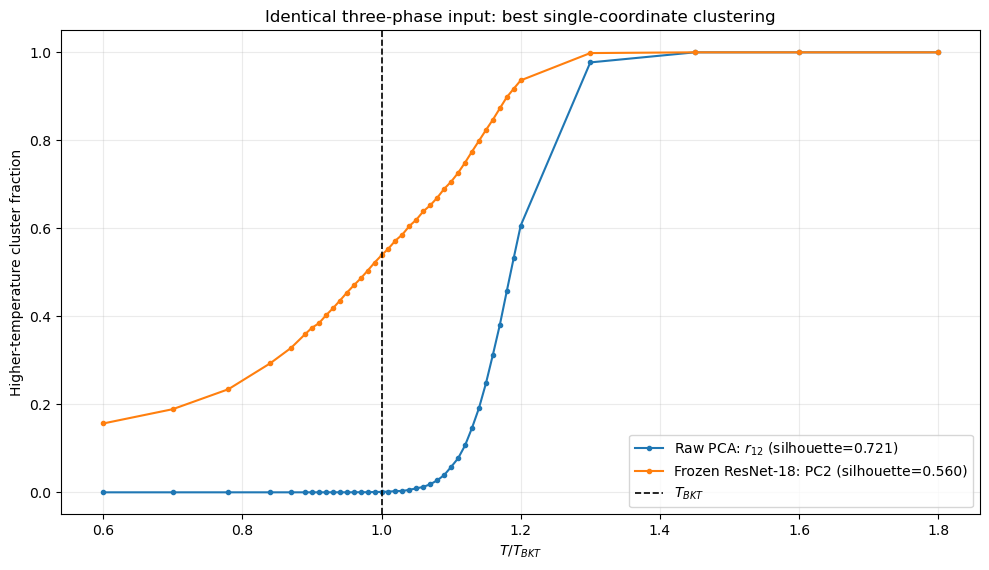

,representation,clustering coordinate,coordinate dimensions,PCs for 90% variance,silhouette,low-T high-cluster fraction,at TBKT high-cluster fraction,high-T high-cluster fraction
0,Raw three-phase PCA,PC1-PC2 radius,2,1158,0.7206,0.0000,0.0010,1.0
1,"Frozen ResNet-18, three-phase input",PC2,1,43,0.5599,0.1564,0.5387,1.0


Cross-representation AMI on matched evaluation set: 0.122


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_mutual_info_score

L=32; N_RUNS=10_000; N_T=41; BINS=10; N=N_RUNS*N_T*BINS; TBKT=.89294
RATIOS=np.array([.60,.70,.78,.84,.87,.89,.90,.91,.92,.93,.94,.95,.96,.97,.98,.99,1.,1.01,1.02,1.03,1.04,1.05,1.06,1.07,1.08,1.09,1.10,1.11,1.12,1.13,1.14,1.15,1.16,1.17,1.18,1.19,1.20,1.30,1.45,1.60,1.80])
ROOT=Path('/home/lledson/senior-thesis/data/processed/xy32_broad/matched_all_bins')
temp_ids=np.tile(np.repeat(np.arange(N_T,dtype=np.int8),BINS),N_RUNS)
fit_bins=(np.arange(N_RUNS)[:,None]+np.arange(N_T)[None,:])%BINS
FIT=((np.arange(N_RUNS)[:,None]*N_T+np.arange(N_T)[None,:])*BINS+fit_bins).reshape(-1)
rng=np.random.default_rng(2401)
EVAL=np.concatenate([rng.choice(np.flatnonzero(temp_ids==ti),125,replace=False) for ti in range(N_T)])

raw=np.load(ROOT/'raw_threephase_pc1-40_scores.npy',mmap_mode='r')
res=np.load(ROOT/'resnet18_pc1-40_scores.npy',mmap_mode='r')
raw_feature=np.sqrt(np.asarray(raw[:,0],np.float32)**2+np.asarray(raw[:,1],np.float32)**2)[:,None]
res_feature=np.asarray(res[:,1],np.float32)[:,None]

def exact_kmeans(feature):
    model=KMeans(2,random_state=42,n_init=10,max_iter=300,algorithm='lloyd').fit(feature[FIT])
    labels=model.predict(feature).astype(np.int8)
    mean_t=[RATIOS[temp_ids[labels==k]].mean() for k in range(2)]
    high=int(np.argmax(mean_t)); high_fraction=np.array([(labels[temp_ids==ti]==high).mean() for ti in range(N_T)])
    sil=float(silhouette_score(feature[EVAL],labels[EVAL]))
    return model,labels,high_fraction,sil,high

raw_model,raw_labels,raw_frac,raw_sil,raw_high=exact_kmeans(raw_feature)
res_model,res_labels,res_frac,res_sil,res_high=exact_kmeans(res_feature)
ami=float(adjusted_mutual_info_score(raw_labels[EVAL],res_labels[EVAL]))

raw_n90=int(np.searchsorted(np.cumsum(np.load(ROOT/'raw_threephase_pca.npz')['eigenvalues']/np.load(ROOT/'raw_threephase_pca.npz')['eigenvalues'].sum()),.9)+1)
res_n90=int(np.searchsorted(np.cumsum(np.load(ROOT/'resnet18_pca.npz')['eigenvalues']/np.load(ROOT/'resnet18_pca.npz')['eigenvalues'].sum()),.9)+1)

fig,ax=plt.subplots(figsize=(10,5.8))
ax.plot(RATIOS,raw_frac,'o-',ms=3,label=fr'Raw PCA: $r_{{12}}$ (silhouette={raw_sil:.3f})')
ax.plot(RATIOS,res_frac,'o-',ms=3,label=fr'Frozen ResNet-18: PC2 (silhouette={res_sil:.3f})')
ax.axvline(1,color='black',ls='--',lw=1.2,label=r'$T_{BKT}$')
ax.set(xlabel=r'$T/T_{BKT}$',ylabel='Higher-temperature cluster fraction',title='Identical three-phase input: best single-coordinate clustering')
ax.grid(alpha=.25); ax.legend(); fig.tight_layout()
fig.savefig(ROOT/'xy32_threephase_best_case_cluster_comparison.png',dpi=220)
plt.show(); plt.close(fig)

summary=pd.DataFrame([
 {'representation':'Raw three-phase PCA','clustering coordinate':'PC1-PC2 radius','coordinate dimensions':2,'PCs for 90% variance':raw_n90,'silhouette':raw_sil,'low-T high-cluster fraction':raw_frac[0],'at TBKT high-cluster fraction':raw_frac[16],'high-T high-cluster fraction':raw_frac[-1]},
 {'representation':'Frozen ResNet-18, three-phase input','clustering coordinate':'PC2','coordinate dimensions':1,'PCs for 90% variance':res_n90,'silhouette':res_sil,'low-T high-cluster fraction':res_frac[0],'at TBKT high-cluster fraction':res_frac[16],'high-T high-cluster fraction':res_frac[-1]},
])
summary.to_csv(ROOT/'xy32_threephase_best_case_summary.csv',index=False)
diagnostics={'same_fit_indices':True,'same_evaluation_indices':True,'fit_observations':len(FIT),'evaluation_observations':len(EVAL),'kmeans':{'clusters':2,'random_state':42,'n_init':10,'algorithm':'lloyd'},'cross_representation_AMI_on_evaluation':ami,'rows':summary.to_dict('records')}
(ROOT/'xy32_threephase_best_case_diagnostics.json').write_text(json.dumps(diagnostics,indent=2))
display(summary.round(4))
print(f'Cross-representation AMI on matched evaluation set: {ami:.3f}')

## What the clean comparison says

Raw PCA gives the cleaner two-cluster geometry, but it requires combining two coordinates with the explicitly rotation-invariant radius. ResNet compresses the complete representation much more strongly and provides a usable **single signed coordinate (PC2)** without manually constructing a ring radius. That is the defensible ResNet advantage here—not a higher silhouette.

Neither unsupervised cluster crossover is automatically an estimate of $T_{BKT}$. At finite size, a clustering boundary can track the strongest change in the chosen representation rather than the thermodynamic transition.

## Physical dissection of the ResNet PCs

Tail averages are ambiguous because they mix several effects and can cancel under global XY rotations. We instead test PC1–PC10 against directly measured physical quantities. For each PC, the table/heatmap reports the larger absolute Pearson correlation obtained from its **signed score** or its **magnitude**. This catches both signed coordinates and ring-like coordinates while clearly recording which form won.

The observables are magnetization magnitude, bond energy, vortex density, harmonic order, low-wavevector structure, and real-space correlations at several distances. Temperature is included only as a diagnostic—not as a physical explanation.

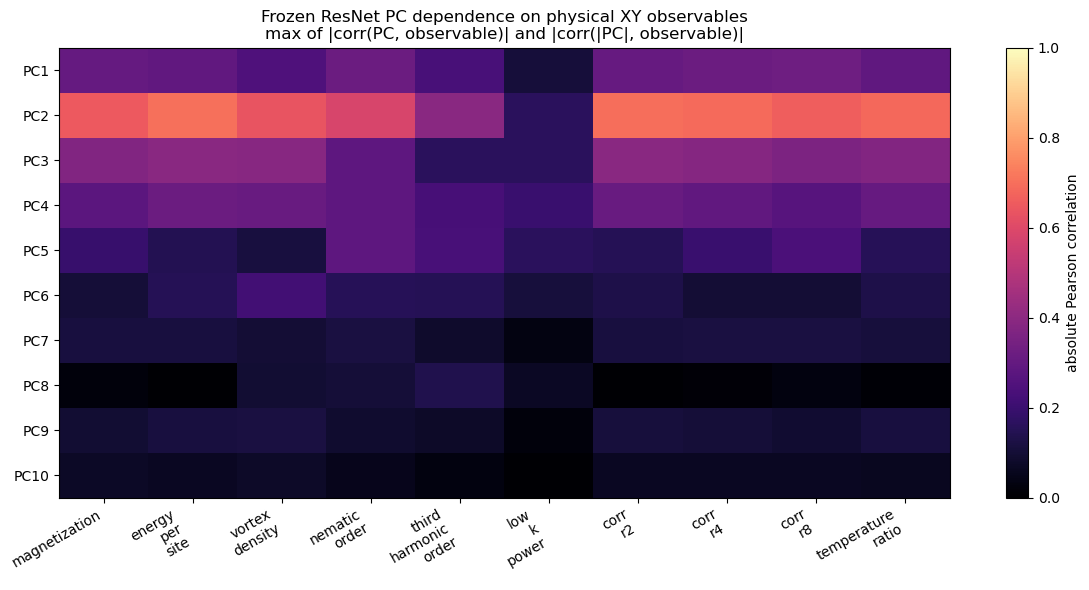

,PC,strongest physical observable,|correlation|,score form,temperature |correlation|,temperature score form
0,1,corr_r8,0.326,signed PC,0.290,signed PC
1,2,energy_per_site,0.700,signed PC,0.686,signed PC
2,3,corr_r2,0.392,signed PC,0.375,signed PC
3,4,energy_per_site,0.318,signed PC,0.306,signed PC
4,5,nematic_order,0.287,signed PC,0.155,|PC| magnitude
5,6,vortex_density,0.218,signed PC,0.133,signed PC
6,7,corr_r8,0.121,|PC| magnitude,0.113,|PC| magnitude
7,8,third_harmonic_order,0.140,signed PC,0.012,signed PC
8,9,vortex_density,0.121,signed PC,0.113,signed PC
9,10,vortex_density,0.077,signed PC,0.062,signed PC


In [2]:
ANGLES=np.load(ROOT/'all_angles_float16.npy',mmap_mode='r')
OBS_PATH=ROOT/'resnet_pc_physical_observables_fit.npz'

def wrap(x): return (x+np.pi)%(2*np.pi)-np.pi

if OBS_PATH.exists():
    saved=np.load(OBS_PATH); observables={k:saved[k] for k in saved.files}
else:
    names=['magnetization','energy_per_site','vortex_density','nematic_order','third_harmonic_order','low_k_power','corr_r2','corr_r4','corr_r8']
    observables={k:np.empty(len(FIT),np.float32) for k in names}
    batch=512
    phase_x=np.exp(-2j*np.pi*np.arange(L)/L).astype(np.complex64)[None,None,:]
    phase_y=np.exp(-2j*np.pi*np.arange(L)/L).astype(np.complex64)[None,:,None]
    for start in range(0,len(FIT),batch):
        stop=min(start+batch,len(FIT)); a=np.asarray(ANGLES[FIT[start:stop]],np.float32); z=np.exp(1j*a)
        observables['magnetization'][start:stop]=np.abs(z.mean((1,2)))
        bx=np.cos(np.roll(a,-1,2)-a).mean((1,2)); by=np.cos(np.roll(a,-1,1)-a).mean((1,2))
        observables['energy_per_site'][start:stop]=-(bx+by)
        d1=wrap(np.roll(a,-1,2)-a)
        ar=np.roll(a,-1,2); ad=np.roll(a,-1,1); adr=np.roll(ar,-1,1)
        circulation=d1+wrap(adr-ar)+wrap(ad-adr)+wrap(a-ad)
        observables['vortex_density'][start:stop]=np.abs(np.rint(circulation/(2*np.pi))).mean((1,2))
        observables['nematic_order'][start:stop]=np.abs(np.exp(2j*a).mean((1,2)))
        observables['third_harmonic_order'][start:stop]=np.abs(np.exp(3j*a).mean((1,2)))
        kx=np.abs((z*phase_x).sum((1,2)))**2/(L**4); ky=np.abs((z*phase_y).sum((1,2)))**2/(L**4)
        observables['low_k_power'][start:stop]=(kx+ky)/2
        for r in (2,4,8):
            observables[f'corr_r{r}'][start:stop]=.5*(np.cos(np.roll(a,-r,2)-a).mean((1,2))+np.cos(np.roll(a,-r,1)-a).mean((1,2)))
    np.savez_compressed(OBS_PATH,**observables)

obs_names=list(observables)+['temperature_ratio']
obs_matrix=np.column_stack([observables[k] for k in observables]+[RATIOS[temp_ids[FIT]]]).astype(np.float64)
pc=np.asarray(res[FIT,:10],np.float64)
def corr_matrix(x,y):
    x=(x-x.mean(0))/x.std(0); y=(y-y.mean(0))/y.std(0)
    return x.T@y/(len(x)-1)
signed=corr_matrix(pc,obs_matrix); magnitude=corr_matrix(np.abs(pc),obs_matrix)
use_magnitude=np.abs(magnitude)>np.abs(signed)
strength=np.where(use_magnitude,np.abs(magnitude),np.abs(signed))

rows=[]
for j in range(10):
    physical=np.arange(len(obs_names)-1); best=physical[np.argmax(strength[j,physical])]
    rows.append({'PC':j+1,'strongest physical observable':obs_names[best],'|correlation|':strength[j,best],'score form':'|PC| magnitude' if use_magnitude[j,best] else 'signed PC','temperature |correlation|':strength[j,-1],'temperature score form':'|PC| magnitude' if use_magnitude[j,-1] else 'signed PC'})
interpretation=pd.DataFrame(rows)
interpretation.to_csv(ROOT/'resnet_pc1-10_physical_interpretation.csv',index=False)

fig,ax=plt.subplots(figsize=(12,6))
im=ax.imshow(strength,aspect='auto',vmin=0,vmax=1,cmap='magma')
ax.set_xticks(range(len(obs_names)),[x.replace('_','\n') for x in obs_names],rotation=30,ha='right')
ax.set_yticks(range(10),[f'PC{i}' for i in range(1,11)])
ax.set_title('Frozen ResNet PC dependence on physical XY observables\nmax of |corr(PC, observable)| and |corr(|PC|, observable)|')
fig.colorbar(im,ax=ax,label='absolute Pearson correlation')
fig.tight_layout(); fig.savefig(ROOT/'resnet_pc1-10_physical_correlations.png',dpi=220); plt.show(); plt.close(fig)
display(interpretation.round(3))

### Physical reading supported by the measurements

- **PC2 is primarily energy/correlation-like:** its strongest association is bond energy ($|r|=0.700$), with similarly broad dependence on magnetization and real-space correlations. Its temperature association ($|r|=0.686$) is slightly weaker than its energy association.
- **PC1 and PC3 emphasize longer- and shorter-range correlations**, respectively, rather than a clean order parameter.
- **PC5 has the clearest nematic contribution.**
- **PC6 and PCs9–10 show the strongest relative vortex-density associations**, although these correlations are modest. They are candidate defect-sensitive directions, not yet pure vortex coordinates.
- PCs beyond the first few are increasingly entangled: no single measured observable explains most of their variation.

### Symmetry and spatial-information stress tests

Correlation alone cannot distinguish cause from coincidence. The following tests directly perturb a matched configuration subset before the frozen network:

- **Global spin rotation:** should not change phase physics; sensitivity indicates color/orientation dependence.
- **Periodic lattice translation:** should not change any bulk observable; sensitivity indicates position/boundary dependence.
- **Spatial permutation:** preserves each configuration's exact one-spin angle histogram and magnetization, while destroying local correlations and vortices. A strong response demonstrates genuinely spatial information.

Values are RMS PC changes divided by that PC's ordinary standard deviation. Zero means invariant; one means the intervention moves the PC by a typical dataset-scale amount.

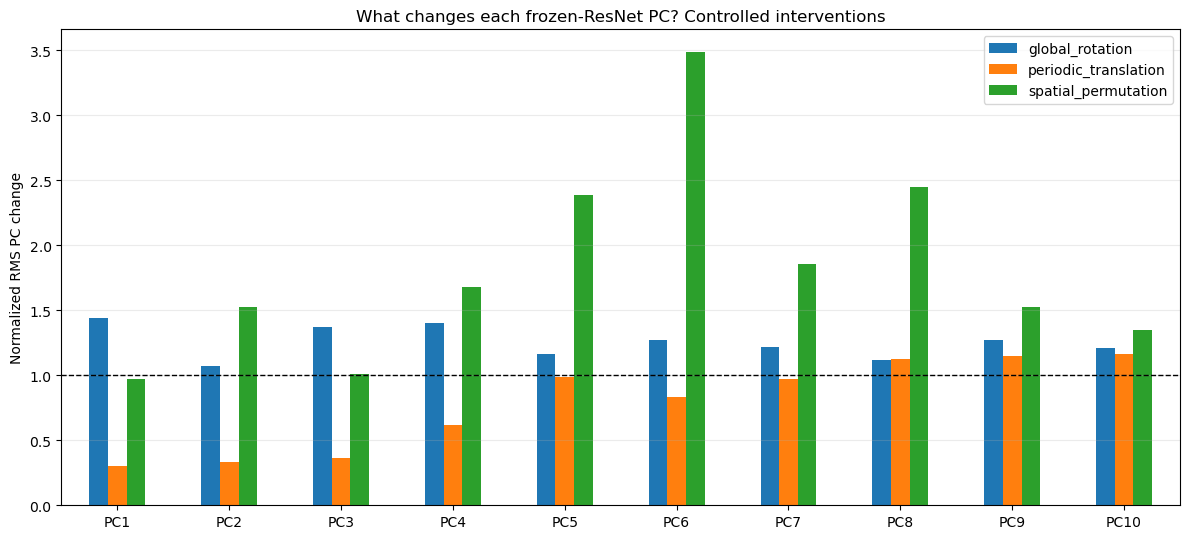

,global_rotation,periodic_translation,spatial_permutation
PC1,1.441,0.302,0.970
PC2,1.074,0.331,1.526
PC3,1.376,0.364,1.011
PC4,1.402,0.618,1.682
PC5,1.168,0.986,2.391
PC6,1.269,0.833,3.488
PC7,1.221,0.968,1.856
PC8,1.117,1.128,2.453
PC9,1.273,1.146,1.528
PC10,1.210,1.167,1.350


In [3]:
STRESS_PATH=ROOT/'resnet_pc1-10_intervention_sensitivity.npz'
if STRESS_PATH.exists():
    q=np.load(STRESS_PATH); stress={k:q[k] for k in q.files}
else:
    import torch
    import torch.nn.functional as F
    from torchvision.models import ResNet18_Weights,resnet18
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    weights=ResNet18_Weights.DEFAULT; model=resnet18(weights=weights); model.fc=torch.nn.Identity(); model.eval().to(device)
    mean=torch.tensor(weights.transforms().mean,device=device).view(1,3,1,1); std=torch.tensor(weights.transforms().std,device=device).view(1,3,1,1)
    phases=torch.tensor([0,-2*np.pi/3,2*np.pi/3],device=device).view(1,3,1,1)
    pca=np.load(ROOT/'resnet18_pca.npz'); mu=torch.tensor(pca['mean'],device=device,dtype=torch.float32); comp=torch.tensor(pca['components'][:10],device=device,dtype=torch.float32)
    sample=FIT[np.random.default_rng(71).choice(len(FIT),2048,replace=False)]; base=np.asarray(ANGLES[sample],np.float32)
    def score_angle(array,batch=256):
        ans=[]
        with torch.inference_mode():
            for s in range(0,len(array),batch):
                a=torch.tensor(array[s:s+batch],device=device).unsqueeze(1)
                image=.5+.5*torch.cos(a+phases); image=F.interpolate(image,size=(224,224),mode='nearest'); image=(image-mean)/std
                emb=model(image); ans.append(((emb-mu)@comp.T).cpu().numpy())
        return np.concatenate(ans)
    base_score=score_angle(base); scale=np.asarray(res[FIT,:10],np.float32).std(0)
    rotations=[]
    for delta in (np.pi/3,2*np.pi/3,np.pi,4*np.pi/3,5*np.pi/3): rotations.append(score_angle(base+delta))
    translations=[]
    for dy,dx in ((3,5),(8,11),(16,16)): translations.append(score_angle(np.roll(base,(dy,dx),(1,2))))
    perm=np.random.default_rng(83).permutation(L*L); shuffled=base.reshape(len(base),-1)[:,perm].reshape(base.shape)
    stress={
      'global_rotation':np.sqrt(np.mean((np.stack(rotations)-base_score[None])**2,axis=(0,1)))/scale,
      'periodic_translation':np.sqrt(np.mean((np.stack(translations)-base_score[None])**2,axis=(0,1)))/scale,
      'spatial_permutation':np.sqrt(np.mean((score_angle(shuffled)-base_score)**2,axis=0))/scale,
    }
    np.savez(STRESS_PATH,**stress)

stress_df=pd.DataFrame(stress,index=[f'PC{i}' for i in range(1,11)])
stress_df.to_csv(ROOT/'resnet_pc1-10_intervention_sensitivity.csv')
ax=stress_df.plot.bar(figsize=(12,5.5)); ax.axhline(1,color='black',ls='--',lw=1); ax.set(ylabel='Normalized RMS PC change',title='What changes each frozen-ResNet PC? Controlled interventions'); ax.grid(axis='y',alpha=.25); plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(ROOT/'resnet_pc1-10_intervention_sensitivity.png',dpi=220); plt.show(); plt.close()
display(stress_df.round(3))

### What the interventions add

PC2 changes by about **1.07 ordinary PC standard deviations under a global spin rotation**, only **0.33** under a periodic lattice translation, and **1.53** when spins are spatially permuted. Thus PC2 is comparatively insensitive to *where* a pattern sits, is strongly dependent on local spatial organization, but still mixes physical texture with the arbitrary three-phase color orientation. Later PCs become substantially more translation-sensitive, warning that they contain ImageNet/resize positional structure as well as XY physics.

## Can ResNet PCs be decoded back into spins?

**Possible, but not uniquely and not with ResNet alone.** ResNet-18 is an encoder; it has no inverse. Furthermore, a reduced PC vector deliberately discards information, so many spin configurations share the same coordinates.

There are two useful approaches:

1. **Constrained activation maximization (recommended next).** Optimize the $32\times32$ angles directly through the frozen differentiable ResNet to raise/lower one PC, while penalizing unphysical high-frequency changes and using many initial configurations/restarts. This shows what causally drives the PC. Compare optimized changes in magnetization, energy, vortex density, and correlation length. It must be checked against adversarial artifacts.
2. **Learned decoder as an information test.** Train a convolutional decoder from the first $k$ PCs to $(\cos\theta,\sin\theta)$ using a circular loss. Before training, canonicalize global spin angle or build rotation equivariance into the decoder; otherwise symmetry-related configurations average into meaningless fields. Reconstruction quality versus $k$ measures retained information, but a generated image is not by itself a physical interpretation.

The safest interpretation protocol combines four forms of evidence: dataset prototypes, observable dependence, invariance/intervention tests, and regularized activation maximization. A PC receives a physical label only when these agree.

## Does a deeper pretrained ResNet help?

ResNet-34, ResNet-50, and ResNet-101 were screened on the same 410,000 temperature-balanced three-phase configurations as ResNet-18. Every model used its standard ImageNet weights and normalization. PCA was fitted to the frozen pooled embedding. Two matched diagnostics were evaluated:

1. **Energy-aligned single coordinate:** among signed PC1–PC10 and their magnitudes, choose the coordinate with the largest absolute bond-energy correlation, then apply exact two-cluster K-means.
2. **Blind PC1–PC40:** exact K-means without selecting a physical coordinate.

This is a depth-ablation screen. The energy-aligned result is intentionally a best-case diagnostic rather than a representation-blind discovery.

,model,embedding_dimensions,PCs_for_90pct,best_energy_PC,score_form,energy_abs_correlation,single_coordinate_silhouette,blind_PC1_40_silhouette,low_T_high_cluster_fraction,at_TBKT_high_cluster_fraction,high_T_high_cluster_fraction
0,resnet101,2048,19,4,signed,0.7461,0.5416,0.3089,0.0107,0.3170,0.9999
1,resnet18,512,43,2,signed,0.6996,0.5682,0.1830,0.1543,0.5381,1.0000
2,resnet34,512,15,2,signed,0.6106,0.5647,0.4053,0.1809,0.3804,1.0000
3,resnet50,2048,8,3,signed,0.7302,0.5533,0.3308,0.0908,0.4168,1.0000


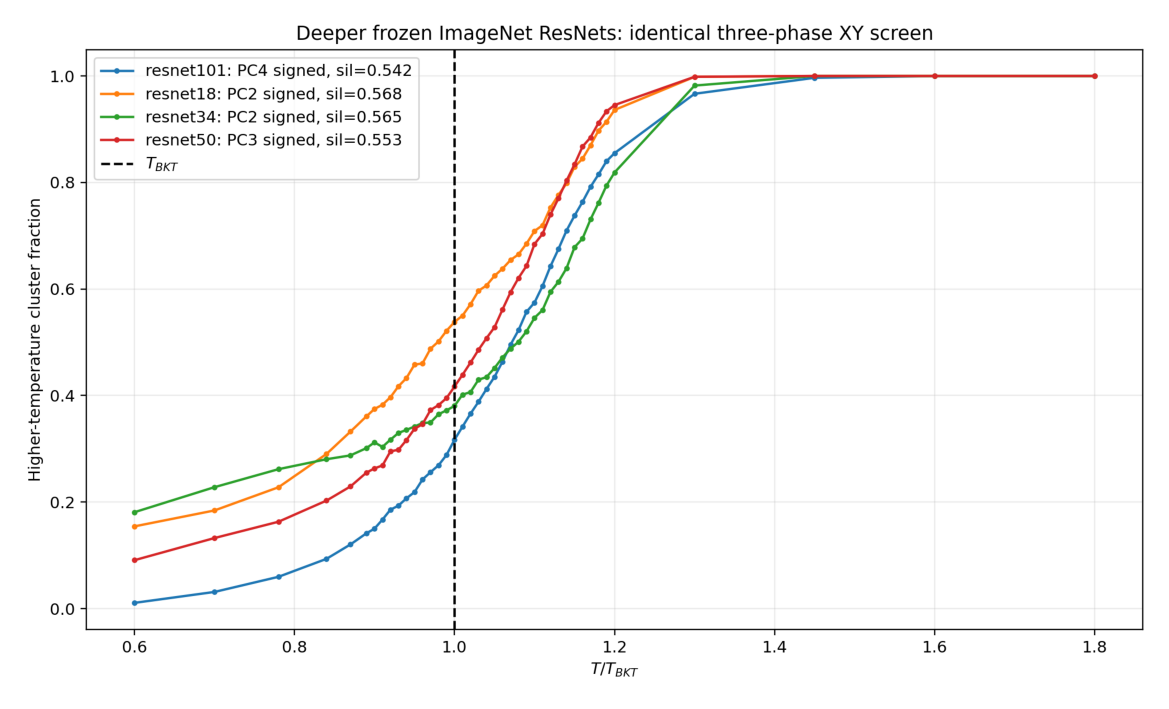

In [4]:
deep=pd.read_csv(ROOT/'xy32_deep_resnet_screen.csv')
display(deep.round(4))
image=plt.imread(ROOT/'xy32_deep_resnet_screen.png')
fig,ax=plt.subplots(figsize=(12,7.2)); ax.imshow(image); ax.axis('off'); fig.tight_layout(); plt.show(); plt.close(fig)

### Depth-ablation conclusion

Depth changes the representation but does **not** overturn the linear baseline result.

- ResNet-50 is the most compact: only **8 PCs** retain 90% of its embedding variance, compared with 43 for ResNet-18.
- Energy alignment improves with bottleneck depth: $|r|=0.730$ for ResNet-50 and $0.746$ for ResNet-101, versus $0.700$ for ResNet-18.
- ResNet-34 gives the best blind 40-PC silhouette (**0.405**, versus 0.183 for ResNet-18), so greater depth can organize the frozen feature space more cleanly without selecting PC2.
- No deeper model improves the best single-coordinate silhouette: ResNet-18 remains highest at **0.568**; the deeper models range from 0.542–0.565.
- All remain below the symmetry-aware raw-PCA radius silhouette (**0.721**).

Thus deeper ImageNet ResNets provide stronger compression, somewhat cleaner blind geometry, and more energy-aligned coordinates—but no better phase separation than the simple symmetry-aware linear representation.